<a href="https://colab.research.google.com/github/lucaser9898/sovereign-funds-rl-portfolio/blob/main/Sharpe_port.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Carica il file dei PREZZI (es. indici_borsa_filtrati.csv):


Saving indici_borsa_filtrati.csv to indici_borsa_filtrati (1).csv
Asset disponibili: 44

=== Portafoglio Max Sharpe — rischio/rendimento annualizzati ===
Rendimento: 11.57% | Volatilità: 13.15% | Sharpe (rf=0): 0.88 | Somma pesi: 1.0000

Carica il file dei PESI (es. pesi_ritracciati.csv):


Saving pesi_ritracciati.csv to pesi_ritracciati (1).csv

=== Value Weighted — rischio/rendimento annualizzati ===
Rendimento: 8.79% | Volatilità: 13.43% | Sharpe (rf=0): 0.65 | Somma pesi: 1.0000

=== Hybrid (Max Sharpe / Value Weighted) — Return & Variance (annualizzati) ===


,w_MaxSharpe,w_ValueWeighted,Ann.Return,Ann.Variance
0,0.00,1.00,8.79%,0.0180
1,0.10,0.90,9.06%,0.0177
2,0.20,0.80,9.34%,0.0174
3,0.30,0.70,9.62%,0.0172
4,0.40,0.60,9.90%,0.0170
5,0.50,0.50,10.18%,0.0169
6,0.60,0.40,10.46%,0.0168
7,0.70,0.30,10.74%,0.0169
8,0.80,0.20,11.01%,0.0169
9,0.90,0.10,11.29%,0.0171


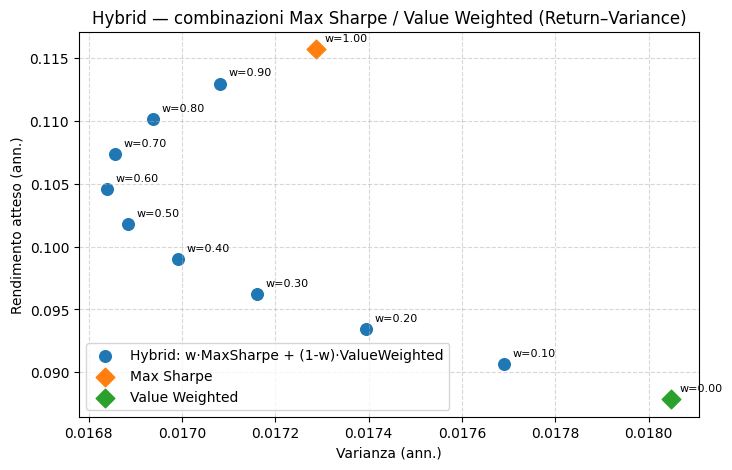


=== Riepilogo (annuale) ===


,Portfolio,Ann.Return,Ann.Volatility,Sharpe (rf=0)
0,MaxSharpe,11.57%,13.15%,0.88
1,ValueWeighted,8.79%,13.43%,0.65



File salvati:
- mapping_MaxSharpe.csv
- pesi_MaxSharpe.csv
- mapping_ValueWeighted.csv
- pesi_ValueWeighted.csv
- rendimenti_mensili_MaxSharpe.csv
- rendimenti_mensili_ValueWeighted.csv
- summary_MaxSharpe_ValueWeighted.csv
- Hybrid_combinazioni_return_variance.csv


In [ ]:

# Requisiti: pandas, numpy, matplotlib, google.colab

import re, difflib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from IPython.display import display

# =========================
# Parametri
# =========================
ANNUALIZATION = 12          #
RISK_FREE = 0.0             #
FUZZY_CUTOFF = 0.55         #
RENORMALIZE_ON_FOUND = True #
PORTFOLIO_COL = None        #
HIDE_ZERO_WEIGHTS = True    #

# Griglia combinazioni per Portafoglio C (w_A in [0,1])
N_COMB = 11                 #

# ---
CUSTOM_WEIGHTS_PERCENT = {  #
    "MSCI Denmark": 42.5,
    "MSCI USA": 30.6,
    "MSCI Switzerland": 12.6,
    "MSCI China": 7.7,
    "MSCI Philippines": 4.1,
    "MSCI Indonesia": 2.3,
    "MSCI Taiwan": 0.3,
    "Others": 0.0
}

# (opzionale)
MANUAL_MAP = {
    # "
    # "

# =========================
# Helper: parsing numeri e normalizzazione nomi
# =========================
def parse_weight(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    is_pct = '%' in s
    s = s.replace('%','').replace(' ', '').replace(',', '.')
    try:
        v = float(s)
    except Exception:
        return np.nan
    if is_pct or v > 1.5:
        v = v / 100.0
    return v

def normalize_name(s: str) -> str:
    if s is None: return ""
    s = str(s).upper()
    REMOVE = [
        r'\bMSCI\b', r'\bINDEX\b', r'\bTRN?\b', r'\bNR\b', r'\bGR\b',
        r'\bNET\b', r'\bNTR\b', r'\bUSD\b', r'\bEUR\b', r'\bPRICE\b'
    ]
    for pat in REMOVE:
        s = re.sub(pat, ' ', s)
    s = re.sub(r'\(.*?\)', ' ', s)
    s = re.sub(r'[^A-Z ]+', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

def make_price_norm_maps(price_cols):
    price_norm_map = {col: normalize_name(col) for col in price_cols}
    norm_to_price = {}
    for orig, norm in price_norm_map.items():
        norm_to_price.setdefault(norm, []).append(orig)
    return price_norm_map, norm_to_price, list(norm_to_price.keys())

# =========================
# Loader robusto dei PESI (riga unica / lungo / wide)
# =========================
def extract_weights_table_any(df, portfolio_col=None):
    df = df.copy()
    df = df[[c for c in df.columns if not str(c).lower().startswith('unnamed')]]

    cols_lower = [c.lower() for c in df.columns]
    # Caso 0: riga unica con intestazioni = asset
    if len(df) == 1 and (df.iloc[0].dropna().shape[0] >= 2):
        row = df.iloc[0]
        sub = pd.DataFrame({'asset': row.index.astype(str), 'weight': row.values})
        sub['weight'] = sub['weight'].apply(parse_weight)
        sub = sub.dropna(subset=['weight'])
        return sub, None

    # Caso A: lungo portfolio/asset/weight
    if set(['portfolio','asset','weight']).issubset(cols_lower):
        m = {c.lower(): c for c in df.columns}
        df2 = df.rename(columns={m['portfolio']:'portfolio', m['asset']:'asset', m['weight']:'weight'})
        portfolios = df2['portfolio'].astype(str).unique().tolist()
        chosen = portfolio_col if (portfolio_col in portfolios) else portfolios[0]
        sub = df2[df2['portfolio'].astype(str) == str(chosen)][['asset','weight']].copy()
        sub['weight'] = sub['weight'].apply(parse_weight)
        sub = sub.dropna(subset=['asset','weight'])
        return sub, chosen

    # Caso B: lungo asset/weight
    if set(['asset','weight']).issubset(cols_lower):
        m = {c.lower(): c for c in df.columns}
        sub = df[[m['asset'], m['weight']]].copy()
        sub.columns = ['asset','weight']
        sub['asset'] = sub['asset'].astype(str)
        sub['weight'] = sub['weight'].apply(parse_weight)
        sub = sub.dropna(subset=['asset','weight'])
        return sub, None

    # Caso C: wide → prima colonna asset, resto = colonne numeriche
    first_col = df.columns[0]
    num_cols = [c for c in df.columns[1:] if pd.to_numeric(df[c], errors='coerce').notna().any()]
    if not num_cols:
        raise ValueError("Nel file pesi non trovo colonne numeriche.")
    chosen = portfolio_col if (portfolio_col in num_cols) else num_cols[0]
    sub = df[[first_col, chosen]].copy()
    sub.columns = ['asset','weight']
    sub['asset'] = sub['asset'].astype(str)
    sub['weight'] = sub['weight'].apply(parse_weight)
    sub = sub.dropna(subset=['asset','weight'])
    return sub, chosen

# =========================
# Matching richiesto → colonne prezzi (exact → normalizzato → fuzzy)
# =========================
def match_assets_to_prices(request_names, request_weights, prices, fuzzy_cutoff=0.55, manual_map=None):
    manual_map = {str(k).upper(): str(v) for k, v in (manual_map or {}).items()}
    price_cols = list(prices.columns)
    _, norm_to_price, price_norm_list = make_price_norm_maps(price_cols)

    mapping_rows = []
    weights_series = pd.Series(0.0, index=price_cols, dtype=float)

    for req, w in zip(request_names, request_weights):
        req_str = "" if req is None else str(req)
        req_up  = req_str.strip().upper()
        if req_up == "OTHERS":
            continue

        # (0) manual map
        if req_up in manual_map:
            chosen = manual_map[req_up]
            if chosen in prices.columns:
                weights_series.loc[chosen] += float(w)
                mapping_rows.append({"Richiesto": req_str, "ColonnaPrezzi": chosen, "Metodo": "MANUAL", "Similarita": 1.0, "PesoInput": w})
                continue
            else:
                mapping_rows.append({"Richiesto": req_str, "ColonnaPrezzi": "(MANUAL NON TROVATA)", "Metodo": "MANUAL_FAIL", "Similarita": 0.0, "PesoInput": w})
                continue

        # (1) match ESATTO (raw)
        if req_str in prices.columns:
            chosen = req_str
            weights_series.loc[chosen] += float(w)
            mapping_rows.append({"Richiesto": req_str, "ColonnaPrezzi": chosen, "Metodo": "EXACT_RAW", "Similarita": 1.0, "PesoInput": w})
            continue

        # (2) match ESATTO normalizzato
        norm_req = normalize_name(req_str)
        if norm_req in norm_to_price:
            chosen = norm_to_price[norm_req][0]
            weights_series.loc[chosen] += float(w)
            mapping_rows.append({"Richiesto": req_str, "ColonnaPrezzi": chosen, "Metodo": "EXACT_NORM", "Similarita": 1.0, "PesoInput": w})
            continue

        # (3) fuzzy
        best = difflib.get_close_matches(norm_req, price_norm_list, n=1, cutoff=fuzzy_cutoff)
        if best:
            choice = best[0]
            score  = difflib.SequenceMatcher(None, norm_req, choice).ratio()
            chosen = norm_to_price[choice][0]
            weights_series.loc[chosen] += float(w)
            mapping_rows.append({"Richiesto": req_str, "ColonnaPrezzi": chosen, "Metodo": "FUZZY", "Similarita": round(score,3), "PesoInput": w})
        else:
            cands = difflib.get_close_matches(norm_req, price_norm_list, n=3, cutoff=0.0)
            mapping_rows.append({"Richiesto": req_str, "ColonnaPrezzi": "(NON TROVATA)", "Metodo": "NONE", "Similarita": 0.0, "PesoInput": w, "Suggerimenti": "; ".join(cands)})

    mapping_df = pd.DataFrame(mapping_rows)
    sum_found = weights_series.sum()
    if sum_found <= 0:
        print("\n[Diagnostica] Esempio colonne PREZZI:", list(prices.columns)[:8])
        print("[Diagnostica] Esempio nomi RICHIESTI:", list(request_names)[:8])
        raise ValueError("Nessun asset dei pesi è stato mappato alle colonne dei prezzi. "
                         "Abbassa FUZZY_CUTOFF o compila MANUAL_MAP.")

    if RENORMALIZE_ON_FOUND:
        weights_series = weights_series / sum_found

    return weights_series, mapping_df

# =========================
# 1) Upload PREZZI (mensili)
# =========================
print("Carica il file dei PREZZI (es. indici_borsa_filtrati.csv):")
up = files.upload()
PRICES_CSV = list(up.keys())[0]
prices = pd.read_csv(PRICES_CSV)

# colonna data
date_cols = [c for c in prices.columns if any(k in c.lower() for k in ["date","data","time"])]
if date_cols:
    prices = prices.rename(columns={date_cols[0]: "Date"})
else:
    if not np.issubdtype(prices.iloc[:,0].dropna().dtype, np.number):
        prices = prices.rename(columns={prices.columns[0]: "Date"})
    else:
        prices.insert(0, "Date", range(len(prices)))

try:
    prices["Date"] = pd.to_datetime(prices["Date"])
except Exception:
    pass
prices = prices.set_index("Date").sort_index()

# solo colonne numeriche (asset)
asset_cols = [c for c in prices.columns if np.issubdtype(prices[c].dropna().dtype, np.number)]
prices = prices[asset_cols]
if prices.shape[1] < 1:
    raise ValueError("Nessuna colonna numerica trovata nel file prezzi.")
print(f"Asset disponibili: {len(prices.columns)}")

# rendimenti mensili
returns_m = prices.pct_change().replace([np.inf, -np.inf], np.nan).dropna(how="any")
if returns_m.empty:
    raise ValueError("Impossibile calcolare i rendimenti (serie troppo corta o dati sporchi).")

# =========================
# 2) Portafoglio A → "Portafoglio Max Sharpe" (etichette)
# =========================
req_names   = list(CUSTOM_WEIGHTS_PERCENT.keys())
req_weights = [CUSTOM_WEIGHTS_PERCENT[k]/100.0 for k in req_names]
weights_A, mapping_A = match_assets_to_prices(req_names, req_weights, prices,
                                              fuzzy_cutoff=FUZZY_CUTOFF, manual_map=MANUAL_MAP)

R_A = returns_m.dot(weights_A)
ann_ret_A = R_A.mean() * ANNUALIZATION
ann_vol_A = R_A.std(ddof=1) * np.sqrt(ANNUALIZATION)
sharpe_A  = (ann_ret_A - RISK_FREE) / ann_vol_A if ann_vol_A > 0 else np.nan

print("\n=== Portafoglio Max Sharpe — rischio/rendimento annualizzati ===")
print(f"Rendimento: {ann_ret_A:.2%} | Volatilità: {ann_vol_A:.2%} | Sharpe (rf=0): {sharpe_A:.2f} | Somma pesi: {weights_A.sum():.4f}")

# =========================
# 3) Portafoglio B → "Value Weighted" (etichette)
# =========================
print("\nCarica il file dei PESI (es. pesi_ritracciati.csv):")
up = files.upload()
WEIGHTS_CSV = list(up.keys())[0]
wraw = pd.read_csv(WEIGHTS_CSV)

weights_tbl, chosen_name = extract_weights_table_any(wraw, PORTFOLIO_COL)
if chosen_name:
    print(f"Colonna/Portfolio pesi selezionata: {chosen_name}")

weights_tbl = weights_tbl.groupby('asset', as_index=False)['weight'].sum()

weights_B, mapping_B = match_assets_to_prices(
    request_names = list(weights_tbl['asset'].values),
    request_weights = list(weights_tbl['weight'].values),
    prices = prices,
    fuzzy_cutoff = FUZZY_CUTOFF,
    manual_map = MANUAL_MAP
)

R_B = returns_m.dot(weights_B)
ann_ret_B = R_B.mean() * ANNUALIZATION
ann_vol_B = R_B.std(ddof=1) * np.sqrt(ANNUALIZATION)
sharpe_B  = (ann_ret_B - RISK_FREE) / ann_vol_B if ann_vol_B > 0 else np.nan

print("\n=== Value Weighted — rischio/rendimento annualizzati ===")
print(f"Rendimento: {ann_ret_B:.2%} | Volatilità: {ann_vol_B:.2%} | Sharpe (rf=0): {sharpe_B:.2f} | Somma pesi: {weights_B.sum():.4f}")

# =========================
# 4) Portafoglio C → "Hybrid" = combinazioni di A (Max Sharpe) e B (Value Weighted)
# =========================
weights_grid = np.round(np.linspace(0.0, 1.0, N_COMB), 2)  # w_A
comb_rows = []
for wA in weights_grid:
    wB = 1.0 - wA
    R_C = wA * R_A + wB * R_B
    ann_ret_C = R_C.mean() * ANNUALIZATION
    ann_var_C = R_C.var(ddof=1) * ANNUALIZATION  # varianza annua
    comb_rows.append({
        "w_MaxSharpe": wA, "w_ValueWeighted": wB,
        "Ann.Return": ann_ret_C,
        "Ann.Variance": ann_var_C
    })

comb_df = pd.DataFrame(comb_rows).sort_values('w_MaxSharpe').reset_index(drop=True)
print("\n=== Hybrid (Max Sharpe / Value Weighted) — Return & Variance (annualizzati) ===")
display(comb_df.style.format({"w_MaxSharpe":"{:.2f}", "w_ValueWeighted":"{:.2f}", "Ann.Return":"{:.2%}", "Ann.Variance":"{:.4f}"}))

# varianza estremi per riferimento
ann_var_A = R_A.var(ddof=1) * ANNUALIZATION
ann_var_B = R_B.var(ddof=1) * ANNUALIZATION

# Grafico Return–Variance delle combinazioni Hybrid
plt.figure(figsize=(8,5))
plt.scatter(comb_df["Ann.Variance"], comb_df["Ann.Return"], s=70, label="Hybrid: w·MaxSharpe + (1-w)·ValueWeighted")
for _, row in comb_df.iterrows():
    plt.annotate(f"w={row['w_MaxSharpe']:.2f}", (row["Ann.Variance"], row["Ann.Return"]),
                 xytext=(6,6), textcoords="offset points", fontsize=8)

# evidenzio anche i due estremi
plt.scatter([ann_var_A], [ann_ret_A], marker='D', s=90, label='Max Sharpe')
plt.scatter([ann_var_B], [ann_ret_B], marker='D', s=90, label='Value Weighted')

plt.xlabel("Varianza (ann.)")
plt.ylabel("Rendimento atteso (ann.)")
plt.title("Hybrid — combinazioni Max Sharpe / Value Weighted (Return–Variance)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# =========================
# 5) Riepilogo & salvataggi CSV (nomi aggiornati)
# =========================
summary = pd.DataFrame({
    'Portfolio': ['MaxSharpe', 'ValueWeighted'],
    'Ann.Return': [ann_ret_A, ann_ret_B],
    'Ann.Volatility': [ann_vol_A, ann_vol_B],
    'Sharpe (rf=0)': [sharpe_A, sharpe_B]
})
print("\n=== Riepilogo (annuale) ===")
display(summary.style.format({'Ann.Return':'{:.2%}', 'Ann.Volatility':'{:.2%}', 'Sharpe (rf=0)':'{:.2f}'}))

# Salvataggi
mapping_A.to_csv("mapping_MaxSharpe.csv", index=False)
pd.Series(weights_A, name='weight').to_csv("pesi_MaxSharpe.csv", header=True)
mapping_B.to_csv("mapping_ValueWeighted.csv", index=False)
pd.Series(weights_B, name='weight').to_csv("pesi_ValueWeighted.csv", header=True)
R_A.to_csv("rendimenti_mensili_MaxSharpe.csv")
R_B.to_csv("rendimenti_mensili_ValueWeighted.csv")
summary.to_csv("summary_MaxSharpe_ValueWeighted.csv", index=False)
comb_df.to_csv("Hybrid_combinazioni_return_variance.csv", index=False)

print("\nFile salvati:")
print("- mapping_MaxSharpe.csv")
print("- pesi_MaxSharpe.csv")
print("- mapping_ValueWeighted.csv")
print("- pesi_ValueWeighted.csv")
print("- rendimenti_mensili_MaxSharpe.csv")
print("- rendimenti_mensili_ValueWeighted.csv")
print("- summary_MaxSharpe_ValueWeighted.csv")
print("- Hybrid_combinazioni_return_variance.csv")


FileNotFoundError: [Errno 2] No such file or directory: 'images/hybrid_return_variance.png'

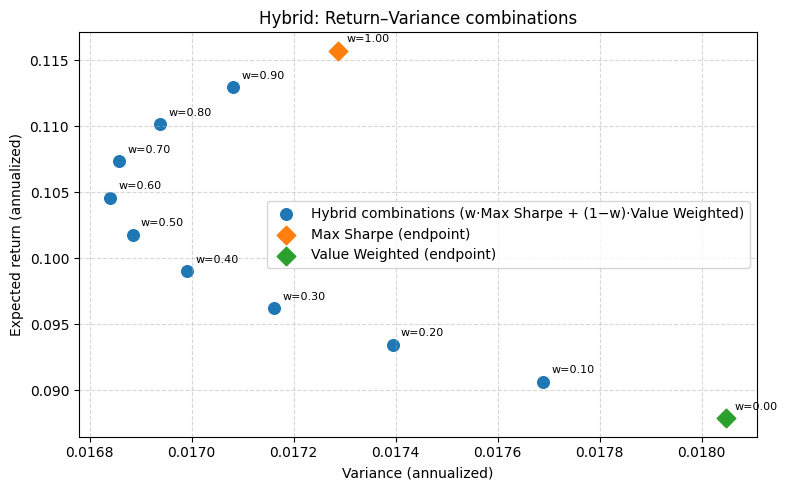

In [ ]:
# ---- Hybrid: Return–Variance combinations (C = w*MaxSharpe + (1-w)*ValueWeighted) ----
# Assumes 'comb_df' has columns: w_MaxSharpe, Ann.Return, Ann.Variance
# and that ann_var_A, ann_var_B, ann_ret_A, ann_ret_B are already computed.

plt.figure(figsize=(8,5))
plt.scatter(comb_df["Ann.Variance"], comb_df["Ann.Return"], s=70,
            label="Hybrid combinations (w·Max Sharpe + (1−w)·Value Weighted)")

# Optional: annotate each point with its weight w for Max Sharpe
for _, row in comb_df.iterrows():
    plt.annotate(f"w={row['w_MaxSharpe']:.2f}",
                 (row["Ann.Variance"], row["Ann.Return"]),
                 xytext=(6,6), textcoords="offset points", fontsize=8)

# Highlight the two endpoints
plt.scatter([ann_var_A], [ann_ret_A], marker='D', s=90, label="Max Sharpe (endpoint)")
plt.scatter([ann_var_B], [ann_ret_B], marker='D', s=90, label="Value Weighted (endpoint)")

plt.xlabel("Variance (annualized)")
plt.ylabel("Expected return (annualized)")
plt.title("Hybrid: Return–Variance combinations")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("images/hybrid_return_variance.png", dpi=300, bbox_inches="tight")
plt.show()
